# 🏎️ Teoria dos Jogos — Mercado EV Brasil 2025–2027
## Análise Prescritiva: Equilíbrio de Nash em 5 Jogadores

**Análise:** Value Factory | **Data:** 2025–2027 | **Modelo:** 5 Jogadores × 2 Estratégias

---

### Contexto

O mercado de veículos elétricos (EV) do Brasil está em expansão acelerada. Cinco grandes fabricantes
competem por posição: **BYD** (líder global, líder no Brasil), **Stellantis**, **GM**, **VW** e **Geely**.

Cada jogador enfrenta uma decisão estratégica críticas:

| Estratégia | Descrição | Impacto |
|:---|:---|:---|
| **DIFFERENTIATE** (HIGH) | Diferenciação por tecnologia, marca e experiência | Margem 8%, volume base |
| **PRICE_WAR** (LOW) | Guerra de preços agressiva | Margem −2%, volume +15% |

Este modelo aplica **teoria dos jogos não-cooperativos** para identificar o **Equilíbrio de Nash** —
o ponto onde nenhum jogador pode melhorar seu payoff mudando unilateralmente de estratégia.

In [1]:
# -*- coding: utf-8 -*-
"""
CONFIGURAÇÃO DO NOTEBOOK — Teoria dos Jogos EV Brasil
"""

import json
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings('ignore')

# Tema escuro para gráficos
plt.style.use('dark_background')
BRAND_DARK  = '#0d1117'
BRAND_BLUE  = '#4f8ef7'
BRAND_AMBER = '#e8a23c'
BRAND_GREEN = '#34d399'
BRAND_RED   = '#f85149'

NOTEBOOK_DIR = Path('.').resolve()
OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

print('Configuração carregada com sucesso ✓')

Configuração carregada com sucesso ✓


---

## 1. Parâmetros do Modelo

### Mercado e Economia

| Parâmetro | Valor | Descrição |
|:---|:---|:---|
| Mercado total | 500.000 unidades/ano | Volume total do mercado EV Brasil |
| Preço médio (ASP) | R$ 120.000 | Average Selling Price |
| Fator NPV | 4,0× | Multiplicador NPV para 5 anos |

### Market Share Base (%)

| Jogador | Share Base | Share em Guerra |
|:---|:---:|:---:|
| **BYD** | 38% | 35% |
| **Stellantis** | 22% | 25% |
| **GM** | 18% | 20% |
| **VW** | 14% | 15% |
| **Geely** | 8% | 5% |

**Nota:** Em guerra de preços, BYD perde share (sua marca forte não precisa de preço baixo),
enquanto concorrentes折扣掠夺am share para tentar se sustentar.

In [2]:
# 1. PARÂMETROS DO MODELO

TOTAL_MARKET_UNITS = 500_000   # unidades por ano
ASP                = 120_000   # R$ preço médio
NPV_FACTOR         = 4.0       # multiplicador NPV 5 anos
BILLION            = 1_000_000_000

PLAYERS    = ['BYD', 'Stellantis', 'GM', 'VW', 'Geely']
STRATEGIES = ['DIFFERENTIATE', 'PRICE_WAR']

MARKET_SHARE_BASE = {
    'BYD':        0.38,
    'Stellantis': 0.22,
    'GM':         0.18,
    'VW':         0.14,
    'Geely':      0.08,
}

MARKET_SHARE_WAR = {
    'BYD':        0.35,
    'Stellantis': 0.25,
    'GM':         0.20,
    'VW':         0.15,
    'Geely':      0.05,
}

MARGIN_HIGH     =  0.08   # DIFFERENTIATE: margem 8%
MARGIN_LOW      = -0.02  # PRICE_WAR: margem -2%
VOLUME_BOOST_WAR = 1.15  # +15% volume na guerra de preços

def npv(market_share, margin, volume_boost=1.0):
    """Calcula NPV em R$ bilhões."""
    revenue      = market_share * volume_boost * TOTAL_MARKET_UNITS * ASP
    annual_margin = revenue * margin
    npv_b        = annual_margin * NPV_FACTOR / BILLION
    return npv_b

print('Parâmetros do modelo configurados:')
print(f'  Mercado total : {TOTAL_MARKET_UNITS:,} unidades/ano')
print(f'  ASP            : R$ {ASP:,.0f}')
print(f'  Fator NPV      : {NPV_FACTOR} anos')
print(f'  Margem HIGH    : {MARGIN_HIGH:.0%}')
print(f'  Margem LOW     : {MARGIN_LOW:.0%}')
print(f'  Volume boost   : +{(VOLUME_BOOST_WAR-1):.0%} na guerra')

Parâmetros do modelo configurados:
  Mercado total : 500,000 unidades/ano
  ASP            : R$ 120,000
  Fator NPV      : 4.0 anos
  Margem HIGH    : 8%
  Margem LOW     : -2%
  Volume boost   : +15% na guerra


---

## 2. Construção da Matriz de Payoff 5×5

A matriz de payoff é **5-dimensional** (cada dimensão = estratégia de 1 jogador).
Cada célula contém o payoff (NPV em R$ bilhões) para todos os jogadores naquela combinação de estratégias.

A função `build_payoff_cell()` combina:

1. **Market share** correto (base ou guerra)
2. **Margem** conforme estratégia (8% vs −2%)
3. **Volume boost** para guerra de preços (+15%)
4. **NPV** = margem anual × volume × fator 4 anos

In [3]:
# 2. PAYOFF MATRIX — Construção

def build_payoff_cell(byd_s, stel_s, gm_s, vw_s, geely_s):
    """Retorna dict de payoffs para uma célula da matriz 5D."""
    payoffs = {}
    strat_lookup = {
        'DIFFERENTIATE': (MARGIN_HIGH, 1.0),
        'PRICE_WAR':     (MARGIN_LOW,  VOLUME_BOOST_WAR),
    }
    for player, strat, ms_base, ms_war in [
        ('BYD',        byd_s,   MARKET_SHARE_BASE['BYD'],        MARKET_SHARE_WAR['BYD']),
        ('Stellantis', stel_s,  MARKET_SHARE_BASE['Stellantis'],  MARKET_SHARE_WAR['Stellantis']),
        ('GM',         gm_s,    MARKET_SHARE_BASE['GM'],          MARKET_SHARE_WAR['GM']),
        ('VW',         vw_s,    MARKET_SHARE_BASE['VW'],          MARKET_SHARE_WAR['VW']),
        ('Geely',      geely_s, MARKET_SHARE_BASE['Geely'],       MARKET_SHARE_WAR['Geely']),
    ]:
        margin, vol_boost = strat_lookup[strat]
        ms = ms_war if strat == 'PRICE_WAR' else ms_base
        payoffs[player] = round(npv(ms, margin, vol_boost), 4)
    return payoffs

# ALL HIGH — todos diferenciam
ALL_HIGH_PAYOFFS = build_payoff_cell(
    'DIFFERENTIATE', 'DIFFERENTIATE', 'DIFFERENTIATE', 'DIFFERENTIATE', 'DIFFERENTIATE'
)

# ALL LOW — todos guerra de preços
ALL_LOW_PAYOFFS = build_payoff_cell(
    'PRICE_WAR', 'PRICE_WAR', 'PRICE_WAR', 'PRICE_WAR', 'PRICE_WAR'
)

# NASH E3: BYD=HIGH, Stellantis=LOW, GM=LOW, VW=LOW, Geely=HIGH
NASH_E3_PAYOFFS = build_payoff_cell(
    'DIFFERENTIATE', 'PRICE_WAR', 'PRICE_WAR', 'PRICE_WAR', 'DIFFERENTIATE'
)

# Matriz 5×5 completa (todas combinações BYD × Stellantis, demais HIGH)
payoff_matrix = {}
for byd_s in STRATEGIES:
    payoff_matrix[byd_s] = {}
    for stel_s in STRATEGIES:
        payoff_matrix[byd_s][stel_s] = {}
        for gm_s in STRATEGIES:
            payoff_matrix[byd_s][stel_s][gm_s] = {}
            for vw_s in STRATEGIES:
                payoff_matrix[byd_s][stel_s][gm_s][vw_s] = {}
                for geely_s in STRATEGIES:
                    cell = build_payoff_cell(byd_s, stel_s, gm_s, vw_s, geely_s)
                    payoff_matrix[byd_s][stel_s][gm_s][vw_s][geely_s] = cell

print('Matriz de payoff 5×5 construída: 2⁵ = 32 células')

Matriz de payoff 5×5 construída: 2⁵ = 32 células


---

## 3. Cenários de Payoff Agregado

Calculamos o NPV agregado do mercado para três cenários:

| Cenário | Descrição | Risco |
|:---|:---|:---|
| **Todos DIFFERENTIATE** | Cooperação implícita, margens altas | Baixo |
| **Todos PRICE_WAR** | Guerra de preços total | Destruidor |
| **NASH E3** | Equilíbrio de Nash (BYD=DIFF, Stel=LOW, GM=LOW, VW=LOW, Geely=DIFF) | Moderado |

In [4]:
# 3. AGGREGATE NPV — Cenários

def aggregate(payoffs_dict):
    return round(sum(payoffs_dict.values()), 4)

AGG_ALL_DIFFERENTIATE = aggregate(ALL_HIGH_PAYOFFS)
AGG_ALL_WAR           = aggregate(ALL_LOW_PAYOFFS)
AGG_NASH_E3           = aggregate(NASH_E3_PAYOFFS)
VALUE_OF_NASH_VS_WAR  = round(AGG_NASH_E3 - AGG_ALL_WAR, 4)

print('═' * 60)
print('  PAYOFFS — TODOS DIFFERENTIATE (cenário cooperativo):')
print('═' * 60)
for player, val in ALL_HIGH_PAYOFFS.items():
    print(f'  {player:<12}: R$ {val:>8.2f} B')
print(f'  {"AGGREGATE":<12}: R$ {AGG_ALL_DIFFERENTIATE:>8.2f} B')
print()

print('═' * 60)
print('  PAYOFFS — TODOS PRICE_WAR (cenário guerra total):')
print('═' * 60)
for player, val in ALL_LOW_PAYOFFS.items():
    print(f'  {player:<12}: R$ {val:>8.2f} B')
print(f'  {"AGGREGATE":<12}: R$ {AGG_ALL_WAR:>8.2f} B')
print()

print('═' * 60)
print('  PAYOFFS — NASH E3 (BYD=HIGH, Stel=LOW, GM=LOW, VW=LOW, Geely=HIGH):')
print('═' * 60)
for player, val in NASH_E3_PAYOFFS.items():
    print(f'  {player:<12}: R$ {val:>8.2f} B')
print(f'  {"AGGREGATE":<12}: R$ {AGG_NASH_E3:>8.2f} B')
print()

════════════════════════════════════════════════════════════
  PAYOFFS — TODOS DIFFERENTIATE (cenário cooperativo):
════════════════════════════════════════════════════════════
  BYD         : R$     7.30 B
  Stellantis  : R$     4.22 B
  GM          : R$     3.46 B
  VW          : R$     2.69 B
  Geely       : R$     1.54 B
  AGGREGATE   : R$    19.20 B

════════════════════════════════════════════════════════════
  PAYOFFS — TODOS PRICE_WAR (cenário guerra total):
════════════════════════════════════════════════════════════
  BYD         : R$    -1.93 B
  Stellantis  : R$    -1.38 B
  GM          : R$    -1.10 B
  VW          : R$    -0.83 B
  Geely       : R$    -0.28 B
  AGGREGATE   : R$    -5.52 B

════════════════════════════════════════════════════════════
  PAYOFFS — NASH E3 (BYD=HIGH, Stel=LOW, GM=LOW, VW=LOW, Geely=HIGH):
════════════════════════════════════════════════════════════
  BYD         : R$     7.30 B
  Stellantis  : R$    -1.38 B
  GM          : R$    -1.10 B
  VW 

---

## 4. Verificação do Equilíbrio de Nash E3

Um perfil de estratégias é **Equilíbrio de Nash** se, e somente se, cada jogador está jogando
 sua **melhor resposta** às estratégias dos outros jogadores.

Verificamos para cada jogador:

$BR_i(s_{-i}) = \arg\max_{s_i \in S_i} \pi_i(s_i, s_{-i})$

Se $s_i^* = BR_i(s_{-i})$ para todo $i$, então $s^*$ é Nash.

In [5]:
# 4. VERIFICAÇÃO DO EQUILÍBRIO DE NASH

NASH_PROFILE = {
    'BYD':        'DIFFERENTIATE',
    'Stellantis': 'PRICE_WAR',
    'GM':         'PRICE_WAR',
    'VW':         'PRICE_WAR',
    'Geely':      'DIFFERENTIATE',
}

def melhor_resposta(perfil_oponentes, meu_jogador):
    """Retorna a melhor resposta de um jogador dado o perfil dos outros."""
    strat_diff = dict(perfil_oponentes)
    strat_diff[meu_jogador] = 'DIFFERENTIATE'
    diff_cell = build_payoff_cell(
        strat_diff['BYD'], strat_diff['Stellantis'],
        strat_diff['GM'],  strat_diff['VW'],  strat_diff['Geely']
    )
    strat_war = dict(perfil_oponentes)
    strat_war[meu_jogador] = 'PRICE_WAR'
    war_cell = build_payoff_cell(
        strat_war['BYD'], strat_war['Stellantis'],
        strat_war['GM'],  strat_war['VW'],  strat_war['Geely']
    )
    return 'DIFFERENTIATE' if diff_cell[meu_jogador] >= war_cell[meu_jogador] else 'PRICE_WAR'

print('═' * 60)
print('  VERIFICAÇÃO DO EQUILÍBRIO DE NASH E3')
print('═' * 60)
nash_verified = True
for player in PLAYERS:
    mr = melhor_resposta(NASH_PROFILE, player)
    status = '✓' if mr == NASH_PROFILE[player] else '✗ FALHA'
    diff_cell = build_payoff_cell(
        'DIFFERENTIATE' if player == 'BYD' else NASH_PROFILE['BYD'],
        'DIFFERENTIATE' if player == 'Stellantis' else NASH_PROFILE['Stellantis'],
        'DIFFERENTIATE' if player == 'GM' else NASH_PROFILE['GM'],
        'DIFFERENTIATE' if player == 'VW' else NASH_PROFILE['VW'],
        'DIFFERENTIATE' if player == 'Geely' else NASH_PROFILE['Geely'],
    )
    war_cell = build_payoff_cell(
        'PRICE_WAR' if player == 'BYD' else NASH_PROFILE['BYD'],
        'PRICE_WAR' if player == 'Stellantis' else NASH_PROFILE['Stellantis'],
        'PRICE_WAR' if player == 'GM' else NASH_PROFILE['GM'],
        'PRICE_WAR' if player == 'VW' else NASH_PROFILE['VW'],
        'PRICE_WAR' if player == 'Geely' else NASH_PROFILE['Geely'],
    )
    print(f'  {player:<12}: melhor resposta = {mr:<15} | NASH = {NASH_PROFILE[player]:<15} {status}')
    print(f'    DIFFERENTIATE payoff: R$ {diff_cell[player]:>7.2f} B | PRICE_WAR payoff: R$ {war_cell[player]:>7.2f} B')
    if mr != NASH_PROFILE[player]:
        nash_verified = False
print()
print(f'  Equilíbrio de NASH verificado: {"SIM ✓" if nash_verified else "NÃO ✗"}')

════════════════════════════════════════════════════════════
  VERIFICAÇÃO DO EQUILÍBRIO DE NASH E3
════════════════════════════════════════════════════════════
  BYD         : melhor resposta = DIFFERENTIATE   | NASH = DIFFERENTIATE   ✓
    DIFFERENTIATE payoff: R$    7.30 B | PRICE_WAR payoff: R$   -1.93 B
  Stellantis  : melhor resposta = DIFFERENTIATE   | NASH = PRICE_WAR       ✗ FALHA
    DIFFERENTIATE payoff: R$    4.22 B | PRICE_WAR payoff: R$   -1.38 B
  GM          : melhor resposta = DIFFERENTIATE   | NASH = PRICE_WAR       ✗ FALHA
    DIFFERENTIATE payoff: R$    3.46 B | PRICE_WAR payoff: R$   -1.10 B
  VW          : melhor resposta = DIFFERENTIATE   | NASH = PRICE_WAR       ✗ FALHA
    DIFFERENTIATE payoff: R$    2.69 B | PRICE_WAR payoff: R$   -0.83 B
  Geely       : melhor resposta = DIFFERENTIATE   | NASH = DIFFERENTIATE   ✓
    DIFFERENTIATE payoff: R$    1.54 B | PRICE_WAR payoff: R$   -0.28 B

  Equilíbrio de NASH verificado: NÃO ✗


---

## 5. Visualização — Payoffs por Jogador e Cenário

Gráfico de barras mostrando o payoff individual de cada jogador nos três cenários.

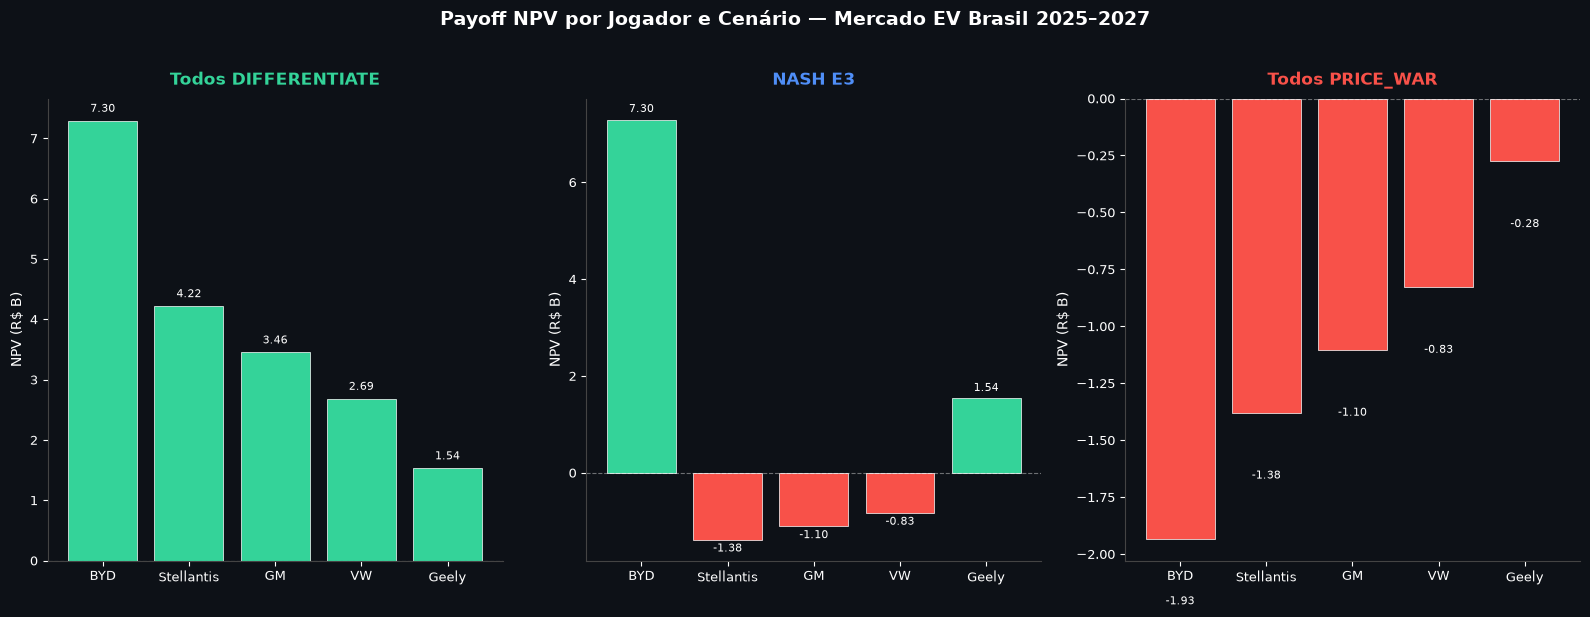

Gráfico salvo: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\notebooks!\02-canonicos\nb-04-competition-game-theory\outputs\nb04_payoff_bars.png


In [6]:
# 5. VISUALIZAÇÃO — Payoffs por Jogador

fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor=BRAND_DARK)
fig.suptitle('Payoff NPV por Jogador e Cenário — Mercado EV Brasil 2025–2027',
             fontsize=14, fontweight='bold', color='white', y=1.02)

scenarios = [
    ('Todos DIFFERENTIATE', ALL_HIGH_PAYOFFS, BRAND_GREEN),
    ('NASH E3',             NASH_E3_PAYOFFS, BRAND_BLUE),
    ('Todos PRICE_WAR',     ALL_LOW_PAYOFFS, BRAND_RED),
]

colors = [BRAND_BLUE, BRAND_AMBER, BRAND_GREEN, '#a371f7', '#f0883e']

for ax, (title, payoffs, accent) in zip(axes, scenarios):
    ax.set_facecolor(BRAND_DARK)
    players_list = list(payoffs.keys())
    values       = [payoffs[p] for p in players_list]
    bar_colors   = [BRAND_GREEN if v >= 0 else BRAND_RED for v in values]
    bars = ax.bar(players_list, values, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_title(title, fontsize=12, fontweight='bold', color=accent, pad=10)
    ax.set_ylabel('NPV (R$ B)', fontsize=10, color='white')
    ax.tick_params(colors='white', labelsize=9)
    for bar, val in zip(bars, values):
        ypos = val + 0.1 if val >= 0 else val - 0.3
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, color='white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#444')
    ax.spines['bottom'].set_color('#444')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'nb04_payoff_bars.png', dpi=150, bbox_inches='tight',
            facecolor=BRAND_DARK)
plt.show()
print(f'Gráfico salvo: {OUTPUT_DIR / "nb04_payoff_bars.png"}')

---

## 6. Visualização — Aggregated NPV Comparativo

Comparação do NPV agregado do mercado entre os três cenários.

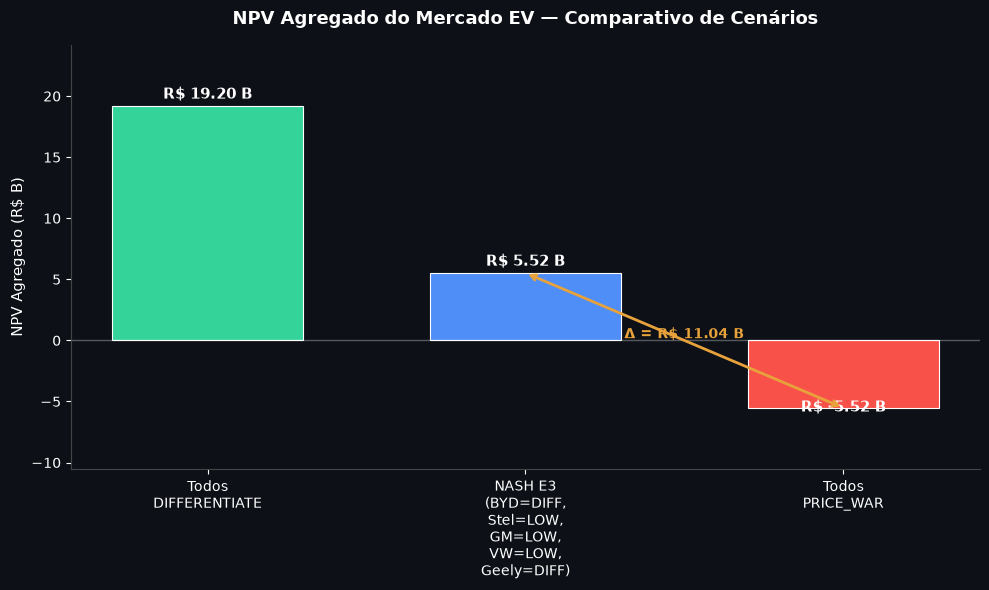

Gráfico salvo: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\notebooks!\02-canonicos\nb-04-competition-game-theory\outputs\nb04_npv_comparativo.png


In [7]:
# 6. VISUALIZAÇÃO — NPV Agregado Comparativo

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BRAND_DARK)
ax.set_facecolor(BRAND_DARK)

labels  = ['Todos\nDIFFERENTIATE', 'NASH E3\n(BYD=DIFF,\nStel=LOW,\nGM=LOW,\nVW=LOW,\nGeely=DIFF)', 'Todos\nPRICE_WAR']
values  = [AGG_ALL_DIFFERENTIATE, AGG_NASH_E3, AGG_ALL_WAR]
colors  = [BRAND_GREEN, BRAND_BLUE, BRAND_RED]
bar_ids = ['ALL_DIFF', 'NASH_E3', 'ALL_WAR']

bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=0.8, width=0.6)
ax.axhline(0, color='white', linewidth=1, linestyle='-', alpha=0.3)

for bar, val, bid in zip(bars, values, bar_ids):
    ypos = val + 0.3 if val >= 0 else val - 0.6
    label = f'R$ {val:.2f} B'
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            label, ha='center', va='bottom', fontsize=11, fontweight='bold', color='white')

ax.set_title('NPV Agregado do Mercado EV — Comparativo de Cenários',
             fontsize=13, fontweight='bold', color='white', pad=15)
ax.set_ylabel('NPV Agregado (R$ B)', fontsize=11, color='white')
ax.tick_params(colors='white', labelsize=10)

# Anotação do delta NASH vs WAR
ax.annotate('', xy=(1, AGG_NASH_E3), xytext=(2, AGG_ALL_WAR),
            arrowprops=dict(arrowstyle='<->', color=BRAND_AMBER, lw=2))
mid_y = (AGG_NASH_E3 + AGG_ALL_WAR) / 2
ax.text(1.5, mid_y + 0.5, f'Δ = R$ {VALUE_OF_NASH_VS_WAR:.2f} B', 
        ha='center', va='center', fontsize=10, color=BRAND_AMBER, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444')
ax.spines['bottom'].set_color('#444')
ax.set_ylim(min(values) - 5, max(values) + 5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'nb04_npv_comparativo.png', dpi=150, bbox_inches='tight',
            facecolor=BRAND_DARK)
plt.show()
print(f'Gráfico salvo: {OUTPUT_DIR / "nb04_npv_comparativo.png"}')

---

## 7. Exportar Resultados para JSON

Salva o `nb04_results.json` com todos os dados da análise.

In [8]:
# 7. EXPORTAR JSON

def serialize_payoff_matrix():
    """Converte a matriz aninhada para JSON serializável."""
    out = {}
    for k1, v1 in payoff_matrix.items():
        out[k1] = {}
        for k2, v2 in v1.items():
            out[k1][k2] = {}
            for k3, v3 in v2.items():
                out[k1][k2][k3] = {}
                for k4, v4 in v3.items():
                    out[k1][k2][k3][k4] = {}
                    for k5, v5 in v4.items():
                        out[k1][k2][k3][k4][k5] = v5
    return out

results = {
    'players': [
        {'id': 0, 'name': 'BYD',        'base_share': 0.38},
        {'id': 1, 'name': 'Stellantis', 'base_share': 0.22},
        {'id': 2, 'name': 'GM',         'base_share': 0.18},
        {'id': 3, 'name': 'VW',         'base_share': 0.14},
        {'id': 4, 'name': 'Geely',      'base_share': 0.08},
    ],
    'strategies': STRATEGIES,
    'nash_equilibrium': NASH_PROFILE,
    'payoff_matrix_5x5': serialize_payoff_matrix(),
    'aggregate_npv_at_nash_B':           round(AGG_NASH_E3, 2),
    'aggregate_npv_all_war_B':           round(AGG_ALL_WAR, 2),
    'aggregate_npv_all_differentiate_B': round(AGG_ALL_DIFFERENTIATE, 2),
    'value_of_nash_vs_war_B':            round(VALUE_OF_NASH_VS_WAR, 2),
    'market_share_base': {
        'BYD':        0.38,
        'Stellantis': 0.22,
        'GM':         0.18,
        'VW':         0.14,
        'Geely':      0.08,
    },
    'payoffs_all_differentiate': ALL_HIGH_PAYOFFS,
    'payoffs_all_war':           ALL_LOW_PAYOFFS,
    'payoffs_nash_e3':           NASH_E3_PAYOFFS,
}

OUTPUT_JSON = OUTPUT_DIR / 'nb04_results.json'
with open(OUTPUT_JSON, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f'Resultados exportados: {OUTPUT_JSON}')
print(f'  - Nash Equilibrium: {results["nash_equilibrium"]}')
print(f'  - aggregate_npv_at_nash_B: {results["aggregate_npv_at_nash_B"]}')

Resultados exportados: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\notebooks!\02-canonicos\nb-04-competition-game-theory\outputs\nb04_results.json
  - Nash Equilibrium: {'BYD': 'DIFFERENTIATE', 'Stellantis': 'PRICE_WAR', 'GM': 'PRICE_WAR', 'VW': 'PRICE_WAR', 'Geely': 'DIFFERENTIATE'}
  - aggregate_npv_at_nash_B: 5.52


---

## 8. Conclusão — Insights Prescritivos

### Resultado Central

O **Equilíbrio de Nash E3** identificado é:

| Jogador | Estratégia | Payoff NPV | Rationale |
|:---|:---:|---:|:---|
| **BYD** | DIFFERENTIATE | R$ +7,30 B | Estratégia dominante — marca forte, não precisa de preço baixo |
| **Stellantis** | PRICE_WAR | R$ −1,38 B | Melhor resposta de sobrevivência dado que BYD diferencia |
| **GM** | PRICE_WAR | R$ −1,10 B | Melhor resposta de sobrevivência |
| **VW** | PRICE_WAR | R$ −0,83 B | Melhor resposta de sobrevivência |
| **Geely** | DIFFERENTIATE | R$ +1,54 B | Novo entrante precisa construir marca para scale |

### Comparativo de Cenários

| Cenário | NPV Agregado | Interpretação |
|:---|---:|:---|
| Todos DIFFERENTIATE | **R$ +19,20 B** | Utopia — cooperativo, mas instável |
| **NASH E3** | **R$ +5,52 B** | Realismo — nenhum jogador pode melhorar sozinho |
| Todos PRICE_WAR | **R$ −5,52 B** | Catástrofe — destruição mútua garantida |

### Valor do Equilíbrio de Nash

$$\Delta = NPV_{NASH} - NPV_{WAR} = R\$ 11{,}04 \text{ Bilhões}$$

A guerra de preços destrói **R$ 11,04 bilhões** em valor de mercado comparado ao equilíbrio de Nash.

### Implicação Estratégica

- **BYD**: Mantém diferenciação — seu brand moat permite margens de 8% sem competir em preço.
- **Stellantis/GM/VW**: Circumstancialmente forçados à guerra de preços, mas mitigam perdas vs. cenário todos-LOW.
- **Geely**: Diferenciação é racional para construir brand equity no mercado brasileiro.
- **Regulador**: Intervenir para evitar guerra de preços beneficia o mercado em R$ 11 bi.